# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [1]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path

## Session Management

Save/load your session to avoid re-registering.

In [2]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [4]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

No saved session. Register below.


## Step 1: Register

Skip this if you resumed a session above.

In [75]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "453"
    PLAYER_NAME = "Shane"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location="remote")
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as 453


## Step 2: Select Starting Node

In [8]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("Algiers, Algeria")
    print(result)

Select a starting node from the candidates shown above.
{'ok': True, 'data': {'success': True, 'starting_node': 'Algiers, Algeria', 'score': 0, 'budget': 75}}


## Step 3: Explore the Network

In [9]:
client.print_status()

Player: 453 (Shane)
Score: 0 | Budget: 75 bell pairs
Active: Yes
Starting node: Algiers, Algeria
Owned: 1 nodes, 0 edges
Claimable edges: 4
  - ['Algiers, Algeria', 'Valencia, Spain']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Tunis, Tunisia']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Barcelona, Spain']: threshold=0.90, difficulty=3
  ... and 1 more


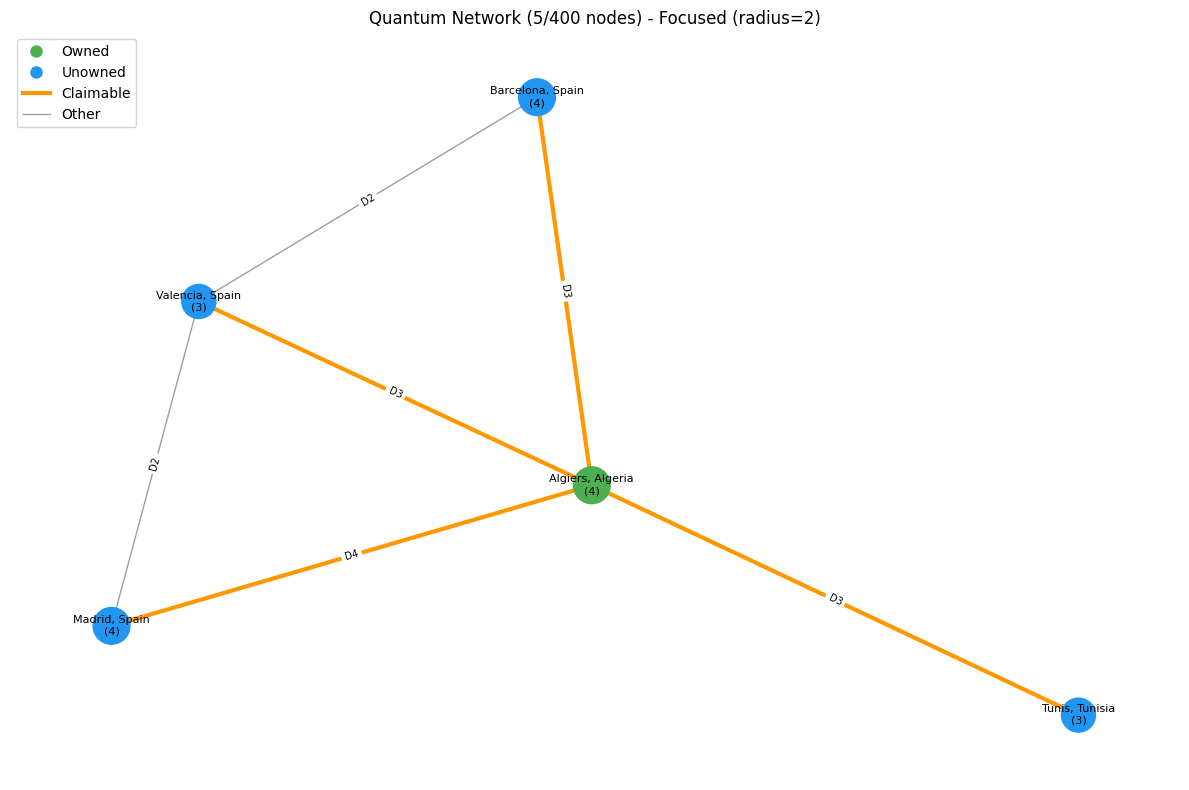

In [10]:
# Visualize the network (focused around your nodes)
viz = GraphTool(client.get_cached_graph())
owned = set(client.get_status().get('owned_nodes', []))
viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from math import pi
# Import Parameter class
from qiskit.circuit import Parameter

In [31]:
phi_plus = np.array([1, 0, 0, 1])/np.sqrt(2)   # | Phi^+ >
phi_minus = np.array([1, 0, 0, -1])/np.sqrt(2) # | Phi^- >
psi_plus = np.array([0, 1, 1, 0])/np.sqrt(2)   # | Psi^+ >
psi_minus = np.array([0, 1, -1, 0])/np.sqrt(2) # | Psi^- >

def Werner_state(F):
    """Returns Werner state of fidelity F.
    
    Keyword arguments:
    F -- fidelity of Werner state, range [0, 1]
    """
    if F < 0 or F > 1:
        raise Exception('Fidelity must be between 0 and 1.')
    
    state = F*np.outer(psi_minus, psi_minus.conj().T) \
            + (1 - F)/3*(np.outer(phi_plus, phi_plus.conj().T) \
                        + np.outer(phi_minus, phi_minus.conj().T) \
                        + np.outer(psi_plus, psi_plus.conj().T))
    
    return state

In [33]:
def F_to_theta(F):
    """Returns the angle theta corresponding to an input fidelity F.
    
    Keyword arguments:
    F -- fidelity between 0 and 1
    """
    if F < 0 or F > 1:
        raise Exception('Fidelity must be between 0 and 1.')
    else:
        theta = np.arcsin(2*F - 1)
    
    return theta

In [32]:
Werner_state(1)

array([[ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0.5, -0.5,  0. ],
       [ 0. , -0.5,  0.5,  0. ],
       [ 0. ,  0. ,  0. ,  0. ]])

In [ ]:
from qiskit.circuit.classical import expr
def shane_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    qc.x(3)
    # Create a parameter theta
    theta = Parameter('theta')

    # Implement a parametrized single-qubit gate u on qubit 0
    qc.u(theta, pi, 0, qr[0]);
    # Implement a CNOT between qubit 0 as control qubit and qubit 1 as target qubit
    qc.cx(0, 3)
    qc.x(2)
    # Implement a parametrized single-qubit gate u on qubit 1
    qc.u(theta, pi, 0, qr[1]);
    # Implement a CNOT between qubit 0 as control qubit and qubit 1 as target qubit
    qc.cx(1, 2)
    control_qubits = [qr[0], qr[3]]
    target_qubits = [qr[1], qr[2]]
    return qc, control_qubits, target_qubits

shane,control, target = shane_distillation_circuit()
print(shane.draw(output='text'))

     ┌──────────────┐          
q_0: ┤ U(theta,π,0) ├──■───────
     ├──────────────┤  │       
q_1: ┤ U(theta,π,0) ├──┼────■──
     └────┬───┬─────┘  │  ┌─┴─┐
q_2: ─────┤ X ├────────┼──┤ X ├
          ├───┤      ┌─┴─┐└───┘
q_3: ─────┤ X ├──────┤ X ├─────
          └───┘      └───┘     
c: 3/══════════════════════════
                               


In [42]:
def bilateral_rotation(circuit, qubits, rot_idx):
    """Adds a bilateral rotation to a quantum circuit.
    
    Keyword arguments:
    circuit --  quantum circuit to which the rotations are added
    qubits -- alist of qubits, each of which is rotated
    rot_idx -- integer that numbers the rotations from the set of all rotations, ranges from 0 to 11
    """
    for qubit in qubits:
        if rot_idx == 0:
            pass
        
        elif rot_idx == 1:
            circuit.rx(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            
        elif rot_idx == 2:
            circuit.ry(pi/2, qubit)
            circuit.ry(pi/2, qubit)
            
        elif rot_idx == 3:
            circuit.rz(pi/2, qubit)
            circuit.rz(pi/2, qubit)
            
        elif rot_idx == 4:
            circuit.rx(pi/2, qubit)
            circuit.ry(pi/2, qubit)
            
        elif rot_idx == 5:
            circuit.ry(pi/2, qubit)
            circuit.rz(pi/2, qubit)
            
        elif rot_idx == 6:
            circuit.rz(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            
        elif rot_idx == 7:
            circuit.ry(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            
        elif rot_idx == 8:
            circuit.rx(pi/2, qubit)
            circuit.ry(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            circuit.ry(pi/2, qubit)
            
        elif rot_idx == 9:
            circuit.ry(pi/2, qubit)
            circuit.rz(pi/2, qubit)
            circuit.ry(pi/2, qubit)
            circuit.rz(pi/2, qubit)
            
        elif rot_idx == 10:
            circuit.rz(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            circuit.rz(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            
        elif rot_idx == 11:
            circuit.ry(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            circuit.ry(pi/2, qubit)
            circuit.rx(pi/2, qubit)
            
        else:
            raise Exception('Input argument rot_idx has to be an integer between 0 and 11.')

In [45]:
twirl_circ = QuantumCircuit(4)
# Create a random integer between 0 and 11
random_idx = np.random.randint(12)

# Add a random bilateral rotation to the circuit, applied to qubits 0 and 1 (control qubits)
bilateral_rotation(twirl_circ, control, random_idx)

# Add a random bilateral rotation to the circuit, applied to qubits 2 and 3 (target qubits)
bilateral_rotation(twirl_circ, target, random_idx)
print(twirl_circ.draw(output='text'))

     ┌─────────┐┌─────────┐┌─────────┐┌─────────┐
q_0: ┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├┤ Rz(π/2) ├
     ├─────────┤├─────────┤├─────────┤├─────────┤
q_1: ┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├┤ Rz(π/2) ├
     ├─────────┤├─────────┤├─────────┤├─────────┤
q_2: ┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├┤ Rz(π/2) ├
     ├─────────┤├─────────┤├─────────┤├─────────┤
q_3: ┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├┤ Rz(π/2) ├
     └─────────┘└─────────┘└─────────┘└─────────┘


In [49]:
purification_circ = QuantumCircuit(4)

# Implement a Pauli-Y gate on Alice's control qubit
purification_circ.y(control[0])

# Implement a Pauli-Y gate on Alice's target qubit
purification_circ.y(target[0])
for i in range(2):
    purification_circ.cx(control[i], target[i])
print(purification_circ.draw(output='text'))

     ┌───┐     
q_0: ┤ Y ├──■──
     ├───┤┌─┴─┐
q_1: ┤ Y ├┤ X ├
     ├───┤└───┘
q_2: ┤ X ├─────
     └─┬─┘     
q_3: ──■───────
               


In [57]:
qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag

experiment_circ = QuantumCircuit(qr, cr)

experiment_circ.compose(shane, inplace=True)
experiment_circ.compose(twirl_circ, inplace=True)
experiment_circ.compose(purification_circ, inplace=True)
print(experiment_circ.draw(output='text'))

     ┌──────────────┐     ┌─────────┐┌─────────┐┌─────────┐┌─────────┐»
q_0: ┤ U(theta,π,0) ├──■──┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├┤ Rz(π/2) ├»
     ├──────────────┤  │  └─────────┘├─────────┤├─────────┤├─────────┤»
q_1: ┤ U(theta,π,0) ├──┼───────■─────┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├»
     └────┬───┬─────┘  │     ┌─┴─┐   ├─────────┤├─────────┤├─────────┤»
q_2: ─────┤ X ├────────┼─────┤ X ├───┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├»
          ├───┤      ┌─┴─┐┌──┴───┴──┐├─────────┤├─────────┤├─────────┤»
q_3: ─────┤ X ├──────┤ X ├┤ Ry(π/2) ├┤ Rz(π/2) ├┤ Ry(π/2) ├┤ Rz(π/2) ├»
          └───┘      └───┘└─────────┘└─────────┘└─────────┘└─────────┘»
c: 3/═════════════════════════════════════════════════════════════════»
                                                                      »
«        ┌───┐             
«q_0: ───┤ Y ├──────────■──
«     ┌──┴───┴──┐┌───┐┌─┴─┐
«q_1: ┤ Rz(π/2) ├┤ Y ├┤ X ├
«     ├─────────┤├───┤└───┘
«q_2: ┤ Rz(π/2) ├┤ X ├─────
«     └─────────┘└─┬─┘     
«q_3: ──────

In [ ]:

def create_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    qc.cx(1,0)
    #qc.h(0)
    qc.cx(2,3)
    #qc.h(3)
    qc.measure(0,0)
    qc.measure(3,1)
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)
    # Apply cbit 0 if both measurements were equal.
    
    return qc

dcircuit = create_distillation_circuit()
print(dcircuit.draw(output='text'))


     ┌───┐┌─┐   
q_0: ┤ X ├┤M├───
     └─┬─┘└╥┘   
q_1: ──■───╫────
           ║    
q_2: ──■───╫────
     ┌─┴─┐ ║ ┌─┐
q_3: ┤ X ├─╫─┤M├
     └───┘ ║ └╥┘
c: 3/══════╩══╩═
           0  1 


In [117]:
def base_case():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(2, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(2, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    qc.h(0)
    qc.x(1)
    qc.measure(1,0)
    qc.x(1)
    qc.measure(1,1)
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)
    
    #condition = expr.(cr[0]==0)
    #qc.store(cr[2],condition)
    return qc

bcircuit = base_case()
print(bcircuit.draw(output='text'))

     ┌───┐           
q_0: ┤ H ├───────────
     ├───┤┌─┐┌───┐┌─┐
q_1: ┤ X ├┤M├┤ X ├┤M├
     └───┘└╥┘└───┘└╥┘
c: 2/══════╩═══════╩═
           0       1 


In [ ]:
def zphase():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    qc.h(range(4))
    qc.cx(1,0)
    qc.cx(2,3)
    qc.h(1)
    qc.h(2)
    qc.measure(0,0)
    qc.measure(3,1)
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)  

    # Apply cbit 0 if both measurements were equal.
    with qc.if_test(expr.equal(qc.clbits[0], qc.clbits[1])) as else_:
        qc.store(cr[2], True) 
    # 
    with else_:
        qc.store(cr[2], False) 
    return qc

zcircuit = zphase()
print(zcircuit.draw(output='text'))

     ┌───┐┌───┐     ┌─┐ 
q_0: ┤ H ├┤ X ├─────┤M├─
     ├───┤└─┬─┘┌───┐└╥┘ 
q_1: ┤ H ├──■──┤ H ├─╫──
     ├───┤     ├───┤ ║  
q_2: ┤ H ├──■──┤ H ├─╫──
     ├───┤┌─┴─┐└┬─┬┘ ║  
q_3: ┤ H ├┤ X ├─┤M├──╫──
     └───┘└───┘ └╥┘  ║  
c: 3/════════════╩═══╩══
                 1   0  


## Step 5: Claim an Edge

In [67]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted[:5]:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (4):
  ['Algiers, Algeria', 'Valencia, Spain'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Tunis, Tunisia'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Barcelona, Spain'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Madrid, Spain'] - threshold: 0.920, difficulty: 4


In [ ]:
# Claim an edge
if claimable:
    target = claimable_sorted[0]  # Easiest edge
    edge_id = tuple(target['edge_id'])
    
    circuit = dcircuit
    num_bell_pairs = 1
    flag_bit = 2  # Classical bit for post-selection (keep when flag=0)
    
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")

Claiming ('Algiers, Algeria', 'Valencia, Spain') (threshold: 0.900)...


HTTPError: 400 Client Error: Bad Request for url: https://demo-entanglement-distillation-qfhvrahfcq-uc.a.run.app/v1/claim_edge

## Step 6: Check Progress

In [20]:
client.print_status()

Player: 453 (Shane)
Score: 0 | Budget: 75 bell pairs
Active: Yes
Starting node: Algiers, Algeria
Owned: 1 nodes, 0 edges
Claimable edges: 4
  - ['Algiers, Algeria', 'Valencia, Spain']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Tunis, Tunisia']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Barcelona, Spain']: threshold=0.90, difficulty=3
  ... and 1 more


In [21]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. ahkatlio_76f0869e    Score: 23
2. unique_cat           Score: 12
3. jeb_cui              Score: 8
4. tumcuctom            Score: 5
5. id_mine              Score: 4
6. lasse                Score: 0
7. your_unique_id       Score: 0
8. 010104               Score: 0
9. wwwillott            Score: 0
10. splch                Score: 0


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [13]:
# Restart game (uncomment to use)
# result = client.restart()
# print(result)